# LV importance (pseudobulk): BRCA_Bassez2021

**Dataset:** Breast cancer tumor: Bassez et al. 2021  
Trains one binary Random Forest per cell type (high vs low proportion),
computes SHAP importance, and annotates top LVs with ARCHS4 model pathways.  
💡 **Environment:** `clamp-analyses`

## Setup

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import balanced_accuracy_score, precision_score

import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'

from pyprojroot.here import here

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

/home/msubirana/miniconda3/envs/clamp-analyses/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters and paths

In [2]:
DATASET_NAME    = 'BRCA_Bassez2021'
MIN_BAL_ACC     = 0.70
MIN_PRECISION   = 0.70
MIN_SAMPLES     = 10     # min samples per class
CUMULATIVE_PCT  = 25     # top LVs covering this % cumulative SHAP
GLOBAL_SEED     = 42

PARAM_GRID = {
    'n_estimators':      [100, 300, 500],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}

OUT_DIR  = here() / "output" / "03_model_biology" / "00_archs4" / "04_pseudobulk" / "BRCA_Bassez2021"
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / 'per_celltype').mkdir(exist_ok=True)

PROJ_CSV     = OUT_DIR / 'projection.csv'
MODEL_SUM    = OUT_DIR / 'model_summary.tsv'
TRUTH_CSV    = here() / 'data' / 'pseudobulk' / DATASET_NAME / 'truthFrac_v0.csv'
ACC_PATH     = OUT_DIR / 'accuracy_summary.tsv'
TOP_LV_PATH  = OUT_DIR / 'top_lvs_cumulative.tsv'
BIO_PATH     = OUT_DIR / 'biology_top_lvs.tsv'
print('Output dir:', OUT_DIR)

Output dir: /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/04_pseudobulk/BRCA_Bassez2021


## Load projection and cell type labels

In [3]:
proj_raw  = pd.read_csv(PROJ_CSV, index_col=0)
lv_matrix = proj_raw.T.copy()   # samples x LVs
lv_matrix.index.name = 'sample'
print('LV matrix (samples x LVs):', lv_matrix.shape)

truth = pd.read_csv(TRUTH_CSV, index_col=0)
print('Cell type proportions:', truth.shape)
truth.head(3)

LV matrix (samples x LVs): (34, 1728)
Cell type proportions: (34, 8)


,B_cell,Cancer_cell,Endothelial_cell,Fibroblast,Mast_cell,Myeloid_cell,T_cell,pDC
BIOKEY_2,0.118516,0.117544,0.025257,0.093064,0.000777,0.101613,0.530600,0.012629
BIOKEY_3,0.009257,0.121206,0.021744,0.661572,0.010980,0.083746,0.090635,0.000861
BIOKEY_4,0.236623,0.119723,0.007059,0.027390,0.002259,0.033743,0.565580,0.007624


In [4]:
# Align samples between projection and truthFrac
shared = lv_matrix.index.intersection(truth.index)
print(f'Shared samples: {len(shared)}')
lv_sub    = lv_matrix.loc[shared]
truth_sub = truth.loc[shared]
cell_types = truth_sub.columns.tolist()
print('Cell types:', cell_types)

Shared samples: 34
Cell types: ['B_cell', 'Cancer_cell', 'Endothelial_cell', 'Fibroblast', 'Mast_cell', 'Myeloid_cell', 'T_cell', 'pDC']


## Load ARCHS4 model pathway annotations

In [5]:
lv_ann = pd.read_csv(MODEL_SUM, sep='\t')
print('Model summary shape:', lv_ann.shape)
lv_ann.head(3)

Model summary shape: (10267, 7)


,pathway,LV,AUC,p_value,FDR,npos,nneg
0,REACTOME_REACTOME_ALPHA_LINOLENIC_OMEGA3_AND_L...,LV1,0.574943,0.356096,0.613156,2,18274
1,REACTOME_REACTOME_BIOTIN_TRANSPORT_AND_METABOLISM,LV1,0.598692,0.313539,0.578455,2,18274
2,REACTOME_REACTOME_MITOCHONDRIAL_TRNA_AMINOACYL...,LV1,0.771957,0.029149,0.116311,4,18274


## Train RF per cell type (high vs low proportion)

In [6]:
X = lv_sub.values.astype(float)
lv_names = lv_sub.columns.tolist()
results = {}

for ct in cell_types:
    proportions = truth_sub[ct].values
    threshold   = np.median(proportions)
    y           = (proportions >= threshold).astype(int)
    n_pos, n_neg = y.sum(), (1 - y).sum()

    if n_pos < MIN_SAMPLES or n_neg < MIN_SAMPLES:
        print(f'{ct}: skipped (n_pos={n_pos}, n_neg={n_neg})')
        continue

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=GLOBAL_SEED)
    rf = RandomForestClassifier(class_weight='balanced', random_state=GLOBAL_SEED, n_jobs=-1)
    search = RandomizedSearchCV(rf, PARAM_GRID, n_iter=10, cv=cv,
                                scoring='balanced_accuracy',
                                random_state=GLOBAL_SEED, n_jobs=-1)
    search.fit(X, y)
    best_rf = search.best_estimator_

    # Evaluate on full data (for SHAP; CV gives generalization estimate)
    y_pred = best_rf.predict(X)
    bal_acc   = balanced_accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, zero_division=0)
    passes    = (bal_acc >= MIN_BAL_ACC) and (precision >= MIN_PRECISION)
    print(f'{ct}: bal_acc={bal_acc:.3f}, precision={precision:.3f}, passes={passes}')

    # SHAP
    explainer  = shap.TreeExplainer(best_rf)
    shap_vals  = explainer.shap_values(X)

    # Handle both old shap (list per class) and new shap (3D array: samples x features x classes)
    if isinstance(shap_vals, list):
        shap_pos = np.array(shap_vals[1])   # (n_samples, n_features)
    elif shap_vals.ndim == 3:
        shap_pos = shap_vals[:, :, 1]        # (n_samples, n_features)
    else:
        shap_pos = shap_vals
    mean_shap  = np.abs(shap_pos[y == 1]).mean(axis=0).ravel()
    shap_df    = pd.DataFrame({'LV': lv_names, 'mean_shap': mean_shap})
    shap_df    = shap_df.sort_values('mean_shap', ascending=False).reset_index(drop=True)
    total_shap = shap_df['mean_shap'].sum()
    shap_df['cumulative_pct'] = shap_df['mean_shap'].cumsum() / total_shap * 100
    shap_df.to_csv(OUT_DIR / 'per_celltype' / f'shap_{ct}.tsv', sep='\t', index=False)

    results[ct] = {'n_pos': int(n_pos), 'n_neg': int(n_neg),
                   'balanced_accuracy': bal_acc, 'precision': precision,
                   'passes': passes, 'rf': best_rf, 'shap_df': shap_df}

print(f'Done. Passing cell types: {sum(v["passes"] for v in results.values())}/{len(results)}')

B_cell: bal_acc=1.000, precision=1.000, passes=True


Cancer_cell: bal_acc=1.000, precision=1.000, passes=True


Endothelial_cell: bal_acc=1.000, precision=1.000, passes=True


Fibroblast: bal_acc=1.000, precision=1.000, passes=True


Mast_cell: bal_acc=1.000, precision=1.000, passes=True


Myeloid_cell: bal_acc=1.000, precision=1.000, passes=True


T_cell: bal_acc=1.000, precision=1.000, passes=True


pDC: bal_acc=1.000, precision=1.000, passes=True
Done. Passing cell types: 8/8


## Save accuracy summary

In [7]:
acc_rows = []
for ct, res in results.items():
    acc_rows.append({'cell_type': ct, 'n_pos': res['n_pos'], 'n_neg': res['n_neg'],
                     'balanced_accuracy': res['balanced_accuracy'],
                     'precision': res['precision'], 'passes': res['passes']})
df_acc = pd.DataFrame(acc_rows)
df_acc.to_csv(ACC_PATH, sep='\t', index=False)
print(df_acc.to_string(index=False))

       cell_type  n_pos  n_neg  balanced_accuracy  precision  passes
          B_cell     17     17                1.0        1.0    True
     Cancer_cell     17     17                1.0        1.0    True
Endothelial_cell     17     17                1.0        1.0    True
      Fibroblast     17     17                1.0        1.0    True
       Mast_cell     17     17                1.0        1.0    True
    Myeloid_cell     17     17                1.0        1.0    True
          T_cell     17     17                1.0        1.0    True
             pDC     17     17                1.0        1.0    True


## Top LVs per cell type (cumulative SHAP)

In [8]:
top_lv_rows = []
top_lvs_by_ct = {}
passing_cts = [ct for ct, res in results.items() if res['passes']]
print('Passing cell types:', passing_cts)

for ct in passing_cts:
    shap_df = results[ct]['shap_df']
    top = shap_df[shap_df['cumulative_pct'] <= CUMULATIVE_PCT]
    if top.empty:
        top = shap_df.iloc[[0]]
    top_lv_rows.append(top.assign(cell_type=ct))
    top_lvs_by_ct[ct] = top['LV'].tolist()

if top_lv_rows:
    df_top = pd.concat(top_lv_rows, ignore_index=True)
    df_top.to_csv(TOP_LV_PATH, sep='\t', index=False)
    print('Top LVs:', df_top.shape)
    print(df_top.groupby('cell_type')['LV'].count())
else:
    df_top = pd.DataFrame()
    print('No passing cell types.')

Passing cell types: ['B_cell', 'Cancer_cell', 'Endothelial_cell', 'Fibroblast', 'Mast_cell', 'Myeloid_cell', 'T_cell', 'pDC']
Top LVs: (157, 4)
cell_type
B_cell              18
Cancer_cell         16
Endothelial_cell    15
Fibroblast          18
Mast_cell           31
Myeloid_cell        21
T_cell              15
pDC                 23
Name: LV, dtype: int64


## Annotate top LVs with pathways

In [9]:
FDR_THRESH = 0.05
AUC_THRESH = 0.7

sig_ann = lv_ann[(lv_ann['AUC'] > AUC_THRESH) & (lv_ann['FDR'] < FDR_THRESH)].copy()
print(f'Significant LV-pathway pairs: {len(sig_ann)}')

bio_rows = []
for ct in passing_cts:
    for lv in top_lvs_by_ct.get(ct, []):
        hits = sig_ann[sig_ann['LV'] == lv][['pathway', 'AUC', 'FDR']]
        if hits.empty:
            bio_rows.append({'cell_type': ct, 'LV': lv,
                             'pathway': 'NO_SIGNIFICANT_PATHWAY', 'AUC': None, 'FDR': None})
        else:
            for _, row in hits.iterrows():
                bio_rows.append({'cell_type': ct, 'LV': lv,
                                 'pathway': row['pathway'], 'AUC': row['AUC'], 'FDR': row['FDR']})

df_bio = pd.DataFrame(bio_rows)
if not df_bio.empty:
    df_bio.to_csv(BIO_PATH, sep='\t', index=False)
    print('Biology rows saved:', df_bio.shape)
    print(df_bio[df_bio.pathway != 'NO_SIGNIFICANT_PATHWAY'].head(10).to_string(index=False))

Significant LV-pathway pairs: 1794


Biology rows saved: (392, 5)
cell_type     LV                                                           pathway      AUC          FDR
   B_cell LV1384               REACTOME_REACTOME_EUKARYOTIC_TRANSLATION_ELONGATION 0.750104 5.283502e-04
   B_cell LV1384 REACTOME_REACTOME_SARS_COV_1_MODULATES_HOST_TRANSLATION_MACHINERY 0.808358 1.067480e-02
   B_cell LV1384                     C8_TRAVAGLINI_LUNG_CD4_MEMORY_EFFECTOR_T_CELL 0.875143 1.897749e-06
   B_cell LV1017    C8_DURANTE_ADULT_OLFACTORY_NEUROEPITHELIUM_GLOBOSE_BASAL_CELLS 0.895278 2.209957e-03
   B_cell LV1017       C8_DURANTE_ADULT_OLFACTORY_NEUROEPITHELIUM_IMMATURE_NEURONS 0.910859 1.469774e-12
   B_cell LV1017                       C8_FAN_EMBRYONIC_CTX_EX_2_EXCITATORY_NEURON 0.982856 1.004443e-02
   B_cell LV1017                                       C8_HU_FETAL_RETINA_AMACRINE 0.892705 1.716839e-05
   B_cell LV1017                                     C8_HU_FETAL_RETINA_HORIZONTAL 0.842388 9.829811e-03
   B_cell LV1017          

## Pathway dotplot (top LVs by SHAP)

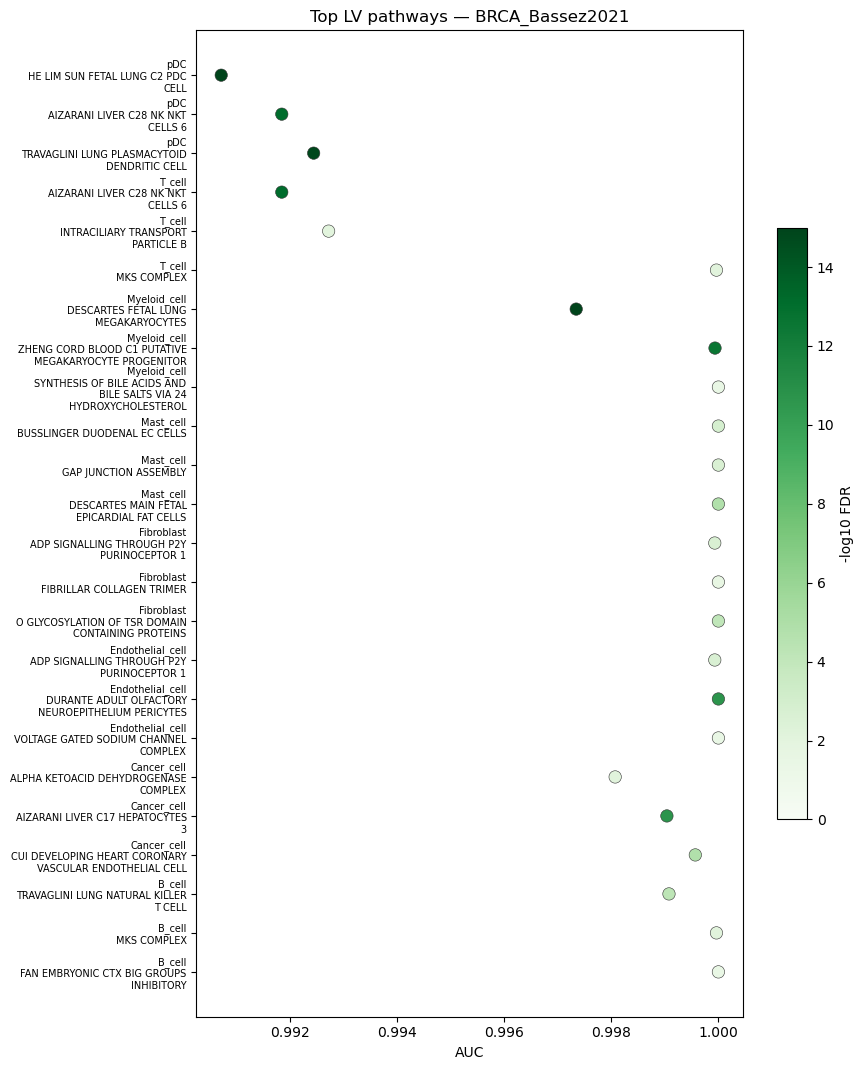

In [10]:
def clean_pw(x):
    for pfx in ['HALLMARK_','REACTOME_REACTOME_','REACTOME_','GOBP_GOBP_','GOBP_',
                'GOCC_GOCC_','GOCC_','GOMF_','C8_','KEGG_']:
        if str(x).upper().startswith(pfx): x = x[len(pfx):]; break
    return x.replace('_', ' ').strip()

if not df_bio.empty and (df_bio['pathway'] != 'NO_SIGNIFICANT_PATHWAY').any():
    plot_df = (
        df_bio[df_bio['pathway'] != 'NO_SIGNIFICANT_PATHWAY']
        .assign(neg_log10_fdr=lambda d: (-np.log10(d['FDR'].clip(1e-20))).clip(upper=15),
                pw_clean=lambda d: d['pathway'].apply(clean_pw))
        .sort_values(['cell_type','AUC'], ascending=[True, False])
        .groupby('cell_type').head(3)
    )
    plot_df['label'] = plot_df['cell_type'] + '\n' + plot_df['pw_clean'].str.wrap(30)

    fig, ax = plt.subplots(figsize=(9, max(4, len(plot_df) * 0.45)))
    sc = ax.scatter(plot_df['AUC'], range(len(plot_df)),
                    s=plot_df['AUC'] * 80, c=plot_df['neg_log10_fdr'],
                    cmap='Greens', vmin=0, vmax=15, edgecolors='#333', linewidths=0.4)
    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(plot_df['label'], fontsize=7)
    ax.set_xlabel('AUC'); ax.set_title(f'Top LV pathways: {DATASET_NAME}')
    plt.colorbar(sc, ax=ax, label='-log10 FDR', shrink=0.6)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'pathway_dotplot.pdf', bbox_inches='tight')
    plt.show()
else:
    print('No significant pathways to plot.')